# Classifying Heart Disease

In this project, Our goal is to try to classify the presence of heart disease in an individual. 

We'll be working with the [Heart Disease Data Set](https://archive.ics.uci.edu/ml/datasets/Heart+Disease) from the UCI Machine Learning Repository. This dataset comes from the famous Cleveland Clinic Foundation, which recorded information on various patient characteristics, including age and chest pain

## Exploring the dataset

In [1]:
# import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Read the dataset
heart = pd.read_csv('../../dataset/heart_disease.csv')

# print a couple of observation.
heart.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,present
0,1,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,2,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,3,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,4,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,5,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [2]:
heart.columns

Index(['Unnamed: 0', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'present'],
      dtype='object')

In [3]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    int64  
 3   cp          303 non-null    int64  
 4   trestbps    303 non-null    int64  
 5   chol        303 non-null    int64  
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     303 non-null    int64  
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    object 
 13  thal        303 non-null    object 
 14  present     303 non-null    int64  
dtypes: float64(1), int64(12), object(2)
memory usage: 35.6+ KB


array([[<Axes: title={'center': 'present'}>]], dtype=object)

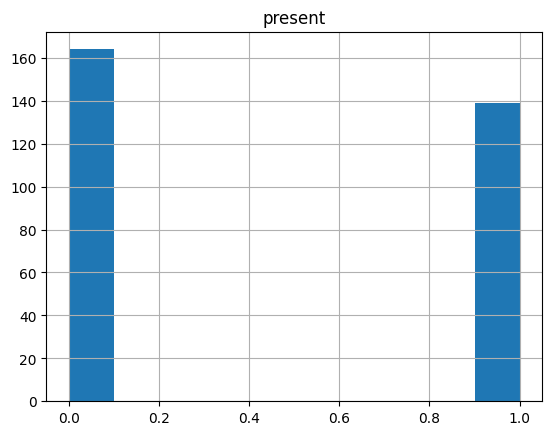

In [4]:
heart.hist('present')

The presence and absence of disease are almost equal in number.

In [5]:
print(heart['ca'].value_counts())
print(heart['thal'].value_counts())
heart = heart[heart['ca'] != '?']
heart = heart[heart['thal'] != '?']
print(heart['ca'].value_counts())
print(heart['thal'].value_counts())

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64
thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64
ca
0.0    174
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64
thal
3.0    164
7.0    115
6.0     18
Name: count, dtype: int64


In [6]:
heart['ca'] = heart['ca'].astype('float')
heart['thal'] = heart['thal'].astype('float')
heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  297 non-null    int64  
 1   age         297 non-null    int64  
 2   sex         297 non-null    int64  
 3   cp          297 non-null    int64  
 4   trestbps    297 non-null    int64  
 5   chol        297 non-null    int64  
 6   fbs         297 non-null    int64  
 7   restecg     297 non-null    int64  
 8   thalach     297 non-null    int64  
 9   exang       297 non-null    int64  
 10  oldpeak     297 non-null    float64
 11  slope       297 non-null    int64  
 12  ca          297 non-null    float64
 13  thal        297 non-null    float64
 14  present     297 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 37.1 KB


In [7]:
# Checking potential predictors
heart.groupby("present").agg(
    {
        "age": "mean",
        "sex": "mean",
        "cp": "mean",
        "trestbps": "mean",
        "chol": "mean",
        "fbs": "mean",
        "restecg": "mean",
        "thalach": "mean",
        "exang": "mean",
        "oldpeak": "mean",
        "slope": "mean",
        "ca": "mean",
        "thal": "mean"
    }
)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
present,,,,,,,,,,,,,
0,52.643750,0.556250,2.793750,129.175000,243.493750,0.143750,0.843750,158.581250,0.143750,0.598750,1.412500,0.275000,3.787500
1,56.759124,0.817518,3.583942,134.635036,251.854015,0.145985,1.175182,139.109489,0.540146,1.589051,1.824818,1.145985,5.832117


Some columns have a small, but noticeable difference when stratified by predictors. Based on the differences and some knowledge about heart disease, these seem like good candidates for predictors:

1. `age`
2. `thalach` (maximum heart rate achieved)
3. `restecg` (resting ECG)
4. `ca` (number of vessels colored by fluoroscopy)

## Dividing the Data

In [8]:
# split the dataset with test size of 25%

X = heart[['age', 'thalach', 'restecg', 'ca']]
y = heart['present']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 742)


In [9]:
# check both the training and test datasets have cases and non-cases.
print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))


present
0    0.567568
1    0.432432
Name: proportion, dtype: float64
present
1    0.546667
0    0.453333
Name: proportion, dtype: float64


Both the training and test set have same proportion of presence of heart disease.

## Building the Model
 

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_train, y_train)
print(accuracy)

0.7522522522522522


In [11]:
# check the traning metics
predictions = model.predict(X_train)
tp = sum((predictions == 1) & (y_train == 1))
fp = sum((predictions == 1) & (y_train == 0))
tn = sum((predictions == 0) & (y_train == 0))
fn = sum((predictions == 0) & (y_train == 1))
sens = tp / (tp + fn)
spec = tn / (tn + fp)

print("Training Accuracy: ", accuracy)
print("Training Sensitivity: ", sens)
print("Training Specificity: ", spec)

Training Accuracy:  0.7522522522522522
Training Sensitivity:  0.6354166666666666
Training Specificity:  0.8412698412698413


Overall the training accuracy was about `75%`, the sensitivity was `63%`, and the specificity was `84%`. Based on these metrics, the model seems to perform better for non-cases.

## Interpreting the Model Coefficients

In [12]:
coefficient = model.coef_
intercept = model.intercept_
print(coefficient)
print(intercept)


[[-0.01883992 -0.04190036  0.28077966  1.12794422]]
[5.99438194]


In [13]:
coefs = ["age", "thalach", "restecg", "ca"]

# Checking in terms of log-odds
for coef, val  in zip(coefs, model.coef_[0]):
    print(coef, ":", round(val, 2))

age : -0.02
thalach : -0.04
restecg : 0.28
ca : 1.13


In [14]:
# Checking in terms of odds
for coef, val  in zip(coefs, model.coef_[0]):
    print(coef, ":", round(np.exp(val), 2))

age : 0.98
thalach : 0.96
restecg : 1.32
ca : 3.09


- Higher age and maximum heart rate (`thalach`) is associated with lower odds of heart disease holding the other predictors constant, but both of these odds ratios are close to 1.
- Resting ECG and the number of colored vessels are associated with higher odds of heart disease holding the other predictors constant. These increases seem to be moderate and high, respectively (a 32% increase and 218% (!) increase).

## Final Model Evaluation

In [15]:
# check the traning metics
predictions = model.predict(X_test)
accuracy = model.score(X_test, y_test)
tp = sum((predictions == 1) & (y_test == 1))
fp = sum((predictions == 1) & (y_test == 0))
tn = sum((predictions == 0) & (y_test == 0))
fn = sum((predictions == 0) & (y_test == 1))
sens = tp / (tp + fn)
spec = tn / (tn + fp)

print("Training Accuracy: ", accuracy)
print("Training Sensitivity: ", sens)
print("Training Specificity: ", spec)

Training Accuracy:  0.7733333333333333
Training Sensitivity:  0.6829268292682927
Training Specificity:  0.8823529411764706


# Conclusions

Test accuracy was 73%, sensitivity was 57%, and specificity was 86%. Compared to the training set, the accuracy didn't change much, while the model fared better with  with non-cases. 